In [ ]:
import jax 
from evosax.algorithms.population_based.simple_ga import crossover as evosax_crossover
import jax.numpy as jnp
import jax.random as jr

jit_simple_function = jax.jit(evosax_crossover)
parent_1 = jnp.array([1.0, 2.0, 3.0])
parent_2 = jnp.array([4.0, 5.0, 6.0])
crossover_rate = 0.5
print(jax.make_jaxpr(jit_simple_function)(key= jr.PRNGKey(0), parent_1=parent_1, parent_2=parent_2, crossover_rate=0.5))

{ lambda ; a:f32[] b:u32[2] c:f32[3] d:f32[3]. let
    e:f32[3] = jit[
      name=crossover
      jaxpr={ lambda ; a:f32[] b:u32[2] c:f32[3] d:f32[3]. let
          f:key<fry>[] = random_wrap[impl=fry] b
          g:f32[3] = jit[
            name=_uniform
            jaxpr={ lambda ; f:key<fry>[] h:f32[] i:f32[]. let
                j:f32[] = convert_element_type[
                  new_dtype=float32
                  weak_type=False
                ] h
                k:f32[] = convert_element_type[
                  new_dtype=float32
                  weak_type=False
                ] i
                l:f32[1] = broadcast_in_dim[
                  broadcast_dimensions=()
                  shape=(1,)
                  sharding=None
                ] j
                m:f32[1] = broadcast_in_dim[
                  broadcast_dimensions=()
                  shape=(1,)
                  sharding=None
                ] k
                n:u32[3] = random_bits[bit_width=32 shape=(3,)] f
   

In [ ]:
import jax
import jax.numpy as jnp
import jax.random as jr
from evosax.algorithms.population_based.simple_ga import crossover as evosax_crossover

# --- Population-level crossover: mimicking evosax's _ask pattern ---
POP_SIZE = 5
DIM = 3

key = jr.PRNGKey(0)
k1, k2, k_cross = jr.split(key, 3)

# Two parent populations
pop1 = jr.uniform(k1, (POP_SIZE, DIM), minval=-5.0, maxval=5.0)
pop2 = jr.uniform(k2, (POP_SIZE, DIM), minval=-5.0, maxval=5.0)
crossover_rate = 0.5

# Evosax pattern: split keys for the batch, then vmap
cross_keys = jr.split(k_cross, POP_SIZE)

pop_crossover = jax.vmap(evosax_crossover, in_axes=(0, 0, 0, None))

print("=== Jaxpr: vmap(evosax_crossover) over populations ===")
print(jax.make_jaxpr(pop_crossover)(cross_keys, pop1, pop2, crossover_rate))

print("\n=== Result ===")
offspring = jax.jit(pop_crossover)(cross_keys, pop1, pop2, crossover_rate)
print(f"pop1 shape: {pop1.shape}, pop2 shape: {pop2.shape}")
print(f"offspring shape: {offspring.shape}")
print(offspring)

=== Jaxpr: vmap(evosax_crossover) over populations ===
{ lambda ; a:u32[5,2] b:f32[5,3] c:f32[5,3] d:f32[]. let
    e:key<fry>[5] = random_wrap[impl=fry] a
    f:f32[5,3] = jit[
      name=_uniform
      jaxpr={ lambda ; e:key<fry>[5] g:f32[] h:f32[]. let
          i:f32[] = convert_element_type[new_dtype=float32 weak_type=False] g
          j:f32[] = convert_element_type[new_dtype=float32 weak_type=False] h
          k:f32[1] = broadcast_in_dim[
            broadcast_dimensions=()
            shape=(1,)
            sharding=None
          ] i
          l:f32[1] = broadcast_in_dim[
            broadcast_dimensions=()
            shape=(1,)
            sharding=None
          ] j
          m:u32[5,3] = random_bits[bit_width=32 shape=(3,)] e
          n:u32[5,3] = shift_right_logical m 9:u32[]
          o:u32[5,3] = or n 1065353216:u32[]
          p:f32[5,3] = bitcast_convert_type[new_dtype=float32] o
          q:f32[5,3] = sub p 1.0:f32[]
          r:f32[1] = sub l k
          s:f32[1,1

In [61]:
op.num_keys_per_atomic_operation

1

In [62]:
import jax, jax.numpy as jnp, jax.random as jr
from malthusjax.operators.crossover.evosax_crossover import EvosaxUniformCrossoverWrapper
from malthusjax.core.genome.real_genome import RealGenome, RealGenomeConfig, RealGenome, RealPopulation


random_p1 = RealPopulation.init_random(
    key=jr.PRNGKey(0),
    config=RealGenomeConfig(shape=(3,), bounds=(-5.0, 5.0)),
    size = 3)
random_p2 = RealPopulation.init_random(
    key=jr.PRNGKey(1),
    config=RealGenomeConfig(shape=(3,), bounds=(-5.0, 5.0) ),
    size = 3
)   

op = EvosaxUniformCrossoverWrapper(crossover_rate=0.5, injection_mode=False).set_typed_keys(False)
key = jr.PRNGKey(42)
keys = jr.split(key, 3)  # injection_mode=True needs 1 key, but we can split more for testing
print(keys)
offspring = op(keys, random_p1, random_p2, 0)
print("Parent 1:", random_p1.values)
print("Parent 2:", random_p2.values)
print("Offspring:", offspring.values)

print(jax.make_jaxpr(op)(keys, random_p1, random_p2, 0))

[[1832780943  270669613]
 [  64467757 2916123636]
 [2465931498  255383827]]
Parent 1: [[ 3.4231412 -3.1762135 -2.728219 ]
 [-4.927062  -4.791088   0.814265 ]
 [ 4.024495   4.1229286 -1.5895236]]
Parent 2: [[ 2.0261526 -2.6516533  3.1786454]
 [-0.9635365  0.48895   -2.773608 ]
 [ 0.5778408 -2.7594483  2.4708128]]
Offspring: [[ 3.4231412 -2.6516533 -2.728219 ]
 [-4.927062  -4.791088  -2.773608 ]
 [ 4.024495   4.1229286  2.4708128]]
{ lambda ; a:u32[3,2] b:f32[3,3] c:f32[3] d:f32[3,3] e:f32[3] f:i32[]. let
    g:u32[3,1,2] = reshape[dimensions=None new_sizes=(3, 1, 2) sharding=None] a
    h:u32[3,1,2] = slice[
      limit_indices=(3, 1, 2)
      start_indices=(0, 0, 0)
      strides=None
    ] g
    i:u32[3,2] = squeeze[dimensions=(1,)] h
    j:key<fry>[3] = random_wrap[impl=fry] i
    k:f32[3,3] = jit[
      name=_uniform
      jaxpr={ lambda ; j:key<fry>[3] l:f32[] m:f32[]. let
          n:f32[] = convert_element_type[new_dtype=float32 weak_type=False] l
          o:f32[] = convert_elem

In [ ]:
cfg = RealGenomeConfig(shape=(3,), bounds=(-5.0, 5.0))
p1 = RealPopulation(genes=RealGenome(values= parent_1),
                    fitness=jnp.zeros(shape=(1,)),
                    config=cfg)
p2 = RealPopulation(genes=RealGenome(values= parent_2),
                    fitness=jnp.zeros(shape=(1,)),
                    config=cfg)
op = EvosaxUniformCrossoverWrapper(crossover_rate=0.5, injection_mode= False).set_typed_keys(True)
key = jr.PRNGKey(42)
keys = jr.split(key, 1)  # injection_mode=True needs 1 key
print(jax.make_jaxpr(op)(keys, p1, p2, cfg))
jit_op = jax.jit(op)
print(jit_op(keys, p1, p2, cfg).genes.values)

{ lambda ; a:u32[1,2] b:f32[3] c:f32[1] d:f32[3] e:f32[1]. let
    f:u32[1,2] = slice[limit_indices=(1, 2) start_indices=(0, 0) strides=None] a
    g:u32[2] = squeeze[dimensions=(0,)] f
    h:key<fry>[] = random_wrap[impl=fry] g
    i:key<fry>[3] = random_split[shape=(3,)] h
    j:u32[3,2] = random_unwrap i
    k:key<fry>[3] = random_wrap[impl=fry] j
    l:f32[3] = jit[
      name=_uniform
      jaxpr={ lambda ; k:key<fry>[3] m:f32[] n:f32[]. let
          o:f32[] = convert_element_type[new_dtype=float32 weak_type=False] m
          p:f32[] = convert_element_type[new_dtype=float32 weak_type=False] n
          q:u32[3] = random_bits[bit_width=32 shape=()] k
          r:u32[3] = shift_right_logical q 9:u32[]
          s:u32[3] = or r 1065353216:u32[]
          t:f32[3] = bitcast_convert_type[new_dtype=float32] s
          u:f32[3] = sub t 1.0:f32[]
          v:f32[] = sub p o
          w:f32[3] = mul u v
          x:f32[3] = add w o
          l:f32[3] = max o x
        in (l,) }
    ] k 

In [29]:
print(jax.make_jaxpr(jit_simple_function)(jnp.array([2.0, 3.0, 4.0])))

{ lambda ; a:f32[3]. let
    b:f32[3] = jit[
      name=simple_function
      jaxpr={ lambda ; a:f32[3]. let
          c:f32[3] = sin a
          d:f32[3] = integer_pow[y=2] a
          e:f32[3] = mul 0.5:f32[] d
          b:f32[3] = add c e
        in (b,) }
    ] a
  in (b,) }


In [5]:
from malthusjax.composer import Composer

# 1. Create a default composer
composer = Composer.create_default()

# 2. Run a quick experiment on the Sphere function
result = composer.quick_run(
    seeds=[42, 43, 44], 
    experiment_name="fast_sphere_opt", 
    output_dir="./results", 
    fitness="sphere:dim=10", # Optimizing a 10D Sphere function
    genome_type="real",      # Continuous real numbers
    genome_length=10,
    bounds=(-5.0, 5.0),
    generations=10, 
    pop_size=32,
    elitism=2
)

# 3. View results
for i in range(3):
    print(f"Run Status: {result.runs[i].status}")
    if result.runs[i].history:
        final_gen = result.runs[i].history[-1]
        print(f"Final Best Fitness: {final_gen['best_fitness']}")

seeds: 100%|██████████| 3/3 [00:05<00:00,  1.76s/it]

Run Status: success
Final Best Fitness: 190.86778259277344
Run Status: success
Final Best Fitness: 184.88369750976562
Run Status: success
Final Best Fitness: 189.2811279296875


In [6]:
import jax
import jax.random as jar

# MalthusJAX Core & Operators
from malthusjax.core.genome.real_genome import RealGenomeConfig
from malthusjax.core.fitness.bbob_evaluator import BBOBEvaluator, BBOBConfig
from malthusjax.operators.selection import ElitePoolSelection
from malthusjax.operators.crossover import SimulatedBinaryCrossover
from malthusjax.operators.mutation import GaussianMutation
from malthusjax.engine import GeneticEngine, GeneticEngineParams

# 1. Define the optimization problem (10-dimensional Sphere function)
genome_config = RealGenomeConfig(shape=(10,), bounds=(-5.0, 5.0))
eval_config = BBOBConfig(maximize=False, fn_name="sphere", num_dims=10, seed=42)
evaluator = BBOBEvaluator.create(eval_config)

# 2. Setup genetic operators
selection = ElitePoolSelection(num_selections=20, elite_k=2)
crossover = SimulatedBinaryCrossover(num_offspring=2, eta=15.0)
mutation = GaussianMutation(num_offspring=1, mutation_rate=0.1, mutation_strength=0.5)

# 3. Initialize the Engine
engine_params = GeneticEngineParams(pop_size=32, elitism=2, num_generations=100)
engine = GeneticEngine(
    engine_params=engine_params,
    genome_config=genome_config,
    evaluator=evaluator,
    selection=selection,
    crossover=crossover,
    mutation=mutation,
    enable_progress_bar=False
)

# 4. Run the evolution loop
key = jar.PRNGKey(42)
state = engine.init_state(rng_key=key)

print(f"Initial Best Fitness: {state.best_fitness:.6f}")

for i in range(engine_params.num_generations):
    state, _ = engine.step(state)
    
    if (i + 1) % 20 == 0:
        print(f"Generation {state.generation}: Best Fitness = {state.best_fitness:.6f}")

print(f"\nEvolution Complete! Final Best Fitness: {state.best_fitness:.6f}")

/var/folders/n8/08b2nd114jdfnsydb_4mj4fw0000gn/T/ipykernel_39723/2243295151.py:36: DeprecationWarning: Legacy PRNGKey detected in GeneticEngine.init_state(). For explicit PRNG backend control use malthusjax.core.random.create_key() or jax.random.key()
  state = engine.init_state(rng_key=key)


Initial Best Fitness: 64.286880
Generation 20: Best Fitness = 294.233215
Generation 40: Best Fitness = 405.393372
Generation 60: Best Fitness = 489.235779
Generation 80: Best Fitness = 585.913818
Generation 100: Best Fitness = 676.336304

Evolution Complete! Final Best Fitness: 676.336304


In [7]:
import jax
import jax.random as jar
import jax.numpy as jnp

from malthusjax.core.genome.real_genome import RealGenomeConfig
from malthusjax.core.fitness.bbob_evaluator import BBOBEvaluator, BBOBConfig
from malthusjax.operators.selection.elite_pool import ElitePoolSelection
from malthusjax.operators.crossover.real import SimulatedBinaryCrossover
from malthusjax.operators.mutation.real import GaussianMutation
from malthusjax.engine.genetic_fastengine import GeneticEngine, GeneticEngineParams

# 1. Setup the Engine (same as synchronous evolution)
genome_config = RealGenomeConfig(shape=(3,), bounds=(-5.0, 5.0))
eval_config = BBOBConfig(maximize=False, fn_name="sphere", num_dims=3, seed=42)
evaluator = BBOBEvaluator.create(eval_config)

engine = GeneticEngine(
    engine_params=GeneticEngineParams(pop_size=30, elitism=2, num_generations=100),
    genome_config=genome_config,
    evaluator=evaluator,
    selection=ElitePoolSelection(num_selections=30, elite_k=3),
    crossover=SimulatedBinaryCrossover(num_offspring=2, eta=15.0),
    mutation=GaussianMutation(num_offspring=1, mutation_rate=0.1, mutation_strength=0.5)
)

# Initialize state
key = jar.PRNGKey(42)
state = engine.init_state(key)

# Mock function to represent an external fitness evaluation
def evaluate_remotely(population):
    # Imagine this sends data to a cluster, runs a physics simulation, etc.
    # Here we just use the built-in evaluator for demonstration
    return engine.evaluator.evaluate_population(population)

print(f"Initial Best Fitness: {state.best_fitness:.6f}")

# 2. The Ask/Tell Loop
for i in range(100): # Number of generations
    # ASK: Get the engine ready with entropy, and grab the current population
    engine_with_entropy, population = engine.ask(state)
    
    # EXTERNALLY EVALUATE: Calculate fitness outside the standard JAX loop
    evaluated_pop = evaluate_remotely(population)
    
    # TELL: Return the evaluated population to generate the next state
    state = engine_with_entropy.tell(state, evaluated_pop)
    
    if (i + 1) % 20 == 0:
        print(f"Generation {state.generation}: Best Fitness = {state.best_fitness:.6f}")

print(f"\nEvolution Complete! Final Best Fitness: {state.best_fitness:.6f}")

/var/folders/n8/08b2nd114jdfnsydb_4mj4fw0000gn/T/ipykernel_39723/599523770.py:28: DeprecationWarning: Legacy PRNGKey detected in GeneticEngine.init_state(). For explicit PRNG backend control use malthusjax.core.random.create_key() or jax.random.key()
  state = engine.init_state(key)


Initial Best Fitness: -79.986763
Generation 20: Best Fitness = -21.245651
Generation 40: Best Fitness = 15.033279
Generation 60: Best Fitness = 33.528076
Generation 80: Best Fitness = 109.857559
Generation 100: Best Fitness = 149.942551

Evolution Complete! Final Best Fitness: 149.942551


In [8]:
import jax
import jax.numpy as jnp
import jax.random as jar

def simple_function(x):
    x = jnp.sin(x) + 0.5 * x**2
    1+1
    return x 

# JIT compile the function for performance
jit_simple_function = jax.jit(simple_function)
result = jit_simple_function(jnp.array([2.0, 3.0, 4.0]))
print (result)

[2.9092975 4.64112   7.2431974]


In [9]:
import jax
import jax.numpy as jnp

key = jax.random.PRNGKey(0)
keys_split = jax.random.split(key, 10)
keys_fold = jax.vmap(lambda i: jax.random.fold_in(key, i))(jnp.arange(10))

print("Raw bits from split (first 2 keys):")
print(keys_split[:2])

print("\nRaw bits from fold_in (first 2 keys):")
print(keys_fold[:2])

# Measure of 'Randomness': Hamming Distance
def bit_diff(k1, k2):
    # Count how many bits are different between two keys
    return bin(k1[0] ^ k2[0]).count('1') + bin(k1[1] ^ k2[1]).count('1')

print(f"\nAvg bit difference (Split): {bit_diff(keys_split[0], keys_split[1])}")
print(f"Avg bit difference (Fold):  {bit_diff(keys_fold[0], keys_fold[1])}")

Raw bits from split (first 2 keys):
[[1797259609 2579123966]
 [ 928981903 3453687069]]

Raw bits from fold_in (first 2 keys):
[[1797259609 2579123966]
 [ 928981903 3453687069]]

Avg bit difference (Split): 34
Avg bit difference (Fold):  34


In [10]:
import jax
import jax.numpy as jnp
from jax.lax import rng_bit_generator

key = jax.random.PRNGKey(42)

def get_raw_bits_fixed(key, count):
    # 1. Manually 'pad' the key from uint32[2] to uint32[4]
    # The low-level engine expects 128 bits of key material.
    low_level_key = jnp.concatenate([key, jnp.zeros(2, dtype=jnp.uint32)])
    
    # 2. Call the generator with the expanded key
    # rng_bit_generator returns (new_key, bits)
    _, bits = rng_bit_generator(low_level_key, (count,), algorithm=1)
    return bits

all_bits = get_raw_bits_fixed(key, 10)
print(f"Success! The raw uint32 at index 7 is: {all_bits[7]}")

Success! The raw uint32 at index 7 is: 1937190183


In [11]:
import jax
import jax.numpy as jnp

key = jax.random.PRNGKey(42)

print("Testing key shapes and types:")
print(f"Original key shape: {key.shape}, dtype: {key.dtype}")
print(f"Original key: {key}")


Testing key shapes and types:
Original key shape: (2,), dtype: uint32
Original key: [ 0 42]


In [12]:
folded_key = jax.random.fold_in(key, 1)
print(f"\nFolded key shape: {folded_key.shape}, dtype: {folded_key.dtype}")
print(f"Folded key: {folded_key}")


Folded key shape: (2,), dtype: uint32
Folded key: [  64467757 2916123636]


In [13]:
split_keys = jax.random.split(key, 10
                              )
print(f"\nSplit keys shape: {split_keys.shape}, dtype: {split_keys.dtype}")
print(f"Split keys: {split_keys}")


Split keys shape: (10, 2), dtype: uint32
Split keys: [[1832780943  270669613]
 [  64467757 2916123636]
 [2465931498  255383827]
 [3134548294  894150801]
 [2954079971 3276725750]
 [2765691542  824333390]
 [2768684296 3055579793]
 [2547012911 1371500959]
 [1016697191 2390192106]
 [1128875147 2463678267]]


In [14]:
from malthusjax.core.random import PRNGImpl, create_key

seed = 42
impls = [PRNGImpl.THREEFRY, PRNGImpl.RBG, PRNGImpl.UNSAFE_RBG]

results = {}
print(f"Seed = {seed}\n")

for impl in impls:
    try:
        k = create_key(seed, impl=impl)
        print(f"{impl.value}: created key with shape {k.shape} and dtype {k.dtype}")
        print(f"fold_in result: {jax.random.fold_in(k, 1)}")
        print('*'*20)
    except Exception as e:
        print(f"{impl.value}: skipped ({e})")
    continue

Seed = 42

threefry2x32: created key with shape () and dtype key<fry>
fold_in result: Array((), dtype=key<fry>) overlaying:
[  64467757 2916123636]
********************
rbg: created key with shape () and dtype key<rbg>
fold_in result: Array((), dtype=key<rbg>) overlaying:
[  64467757 2916123636   64467757 2916123636]
********************
unsafe_rbg: created key with shape () and dtype key<urbg>
fold_in result: Array((), dtype=key<urbg>) overlaying:
[1241004809 2575482513 3127841254 2618439148]
********************


In [15]:
def jit_fold_in(key, i):
    return jax.random.fold_in(key, i)

jit_fn = jax.jit(jit_fold_in)
print(jit_fn.lower(key, 1).compile().as_text())

HloModule jit_jit_fold_in, is_scheduled=true, entry_computation_layout={(u32[2]{0}, s32[])->u32[2]{0}}, allow_spmd_sharding_propagation_to_parameters={true,true}, allow_spmd_sharding_propagation_to_output={true}

%fused_computation.2 (param_0.10: u32[2]) -> u32[] {
  %param_0.10 = u32[2]{0} parameter(0)
  %slice.32 = u32[1]{0} slice(%param_0.10), slice={[0:1]}, metadata={op_name="jit(jit_fold_in)/jit(_threefry_fold_in)/slice" source_file="/var/folders/n8/08b2nd114jdfnsydb_4mj4fw0000gn/T/ipykernel_39723/3481045929.py" source_line=2 source_end_line=2 source_column=11 source_end_column=37}
  %bitcast.10 = u32[] bitcast(%slice.32), metadata={op_name="jit(jit_fold_in)/jit(_threefry_fold_in)/slice" source_file="/var/folders/n8/08b2nd114jdfnsydb_4mj4fw0000gn/T/ipykernel_39723/3481045929.py" source_line=2 source_end_line=2 source_column=11 source_end_column=37}
  %slice.31 = u32[1]{0} slice(%param_0.10), slice={[1:2]}, metadata={op_name="jit(jit_fold_in)/jit(_threefry_fold_in)/slice" source_fi

In [16]:
from malthusjax.core.random import PRNGImpl, create_key
import jax, jax.numpy as jnp, jax.random as jr

seed = 42
impls = [PRNGImpl.THREEFRY, PRNGImpl.RBG, PRNGImpl.UNSAFE_RBG]

print(f"Comparing split() outputs for seed = {seed}\n")

for impl in impls:
    try:
        k = create_key(seed, impl=impl)
        split_keys = jr.split(k, 4)
        print(f"{impl.value}:")
        print(f"  Key dtype: {k.dtype}")
        print(f"  Split result shape: {split_keys.shape}")
        print(f"  First split key: {split_keys[0]}")
        print(f"  Second split key: {split_keys[1]}")
        print('*'*20)
    except Exception as e:
        print(f"{impl.value}: ERROR - {e}\n")

# Show that they produce different random values
print("Random uniform values from same seed:")
for impl in impls:
    try:
        k = create_key(seed, impl=impl)
        vals = jr.uniform(k, shape=(3,))
        print(f"{impl.value}: {vals}")
    except Exception as e:
        print(f"{impl.value}: ERROR - {e}")

Comparing split() outputs for seed = 42

threefry2x32:
  Key dtype: key<fry>
  Split result shape: (4,)
  First split key: Array((), dtype=key<fry>) overlaying:
[1832780943  270669613]
  Second split key: Array((), dtype=key<fry>) overlaying:
[  64467757 2916123636]
********************
rbg:
  Key dtype: key<rbg>
  Split result shape: (4,)
  First split key: Array((), dtype=key<rbg>) overlaying:
[1832780943  270669613 1832780943  270669613]
  Second split key: Array((), dtype=key<rbg>) overlaying:
[  64467757 2916123636   64467757 2916123636]
********************
unsafe_rbg:
  Key dtype: key<urbg>
  Split result shape: (4,)
  First split key: Array((), dtype=key<urbg>) overlaying:
[2620864722 2991908441  282133475 2589630650]
  Second split key: Array((), dtype=key<urbg>) overlaying:
[4105776319  298289174  864345282  274752888]
********************
Random uniform values from same seed:
threefry2x32: [0.48870957 0.6797972  0.6162715 ]
rbg: [0.6102176  0.69660795 0.06568921]
unsafe_rbg:

## Fitness comparison: Evosax vs Malthus ✅

This notebook cell runs a controlled comparison between an Evosax strategy (via
`EvosaxEngineAdapter`) and the built-in Malthus `GeneticEngine` (via
`GeneticEngineAdapter`). It:

- Uses the **same problem** (BBOB sphere), population size and number of generations
- Runs multiple **seeds** to estimate variability
- Aggregates per-generation **mean ± std** of best fitness across seeds
- Plots the learning curves and prints summary statistics (final best fitness and time)

Default settings are conservative so the cell runs quickly. Edit `SEEDS`,
`POP_SIZE` or `GENERATIONS` below to increase fidelity.


Running 3 seeds: [42, 123, 999] — this may take a moment...


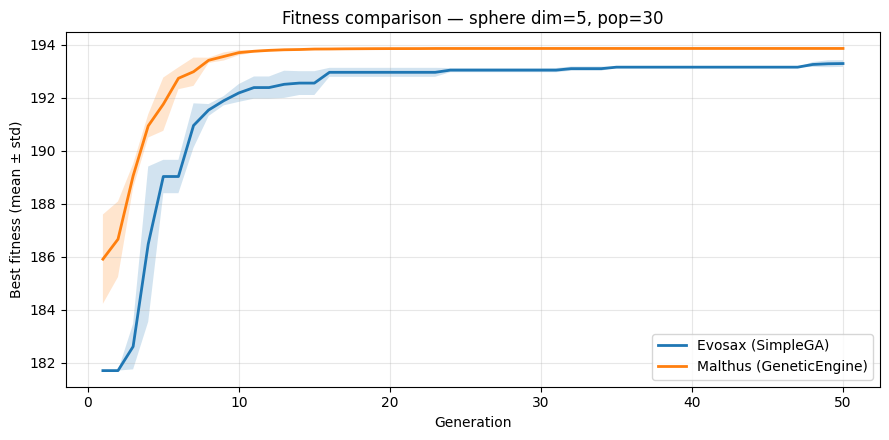


Summary (mean_final, std_final, mean_evolution_time):
Evosax: (193.28775024414062, 0.1263061761856079, 0.020718859508633614)
Malthus: (193.856689453125, 3.632318112067878e-05, 0.40107855200767517)

Final mean difference (Evosax - Malthus): -0.568939208984375

Tip: Increase SEEDS and/or GENERATIONS for more robust comparisons.


In [3]:
# Evosax vs Malthus fitness comparison (with controlled initial population)
import matplotlib.pyplot as plt
import numpy as np
import jax.random as jr
import jax.numpy as jnp

from malthusjax.composer.evosax_adapter import build_evosax_engine
from malthusjax.composer.catalog import OperatorCatalog
from malthusjax.composer.engine_factory import build_engine_from_catalog

# --- Experiment configuration (change as needed) ---
PROBLEM = "sphere"
DIM = 5
POP_SIZE = 30
GENERATIONS = 50
SEEDS = [42, 123, 999]
EVOSAX_STRAT = "SimpleGA"

# --- Shared initial population (ensure both engines start identically) ---
BASE_KEY = jr.PRNGKey(0)
INITIAL_POP = jr.uniform(BASE_KEY, (POP_SIZE, DIM), minval=-5.0, maxval=5.0)

# --- Build Evosax adapter (provide initial_population) ---
evosax_adapter = build_evosax_engine(
    strategy_name=EVOSAX_STRAT,
    problem_name=PROBLEM,
    num_dims=DIM,
    pop_size=POP_SIZE,
    generations=GENERATIONS,
    maximize=True,
    initial_population=INITIAL_POP,
)

# --- Build Malthus (GeneticEngine) adapter via catalog and supply the same initial population ---
cat = OperatorCatalog()
fitness = cat.get(f"{PROBLEM}:dim={DIM}")
selection = cat.get(f"tournament:num_selections={POP_SIZE//2},tournament_size=3")
crossover = cat.get("blend:alpha=0.5")
mutation = cat.get("gaussian:mutation_rate=0.1")

malthus_adapter = build_engine_from_catalog(
    {
        "fitness": fitness,
        "selection": selection,
        "crossover": crossover,
        "mutation": mutation,
    },
    {
        "genome_type": "real",
        "pop_size": POP_SIZE,
        "generations": GENERATIONS,
        "genome_length": DIM,
        "bounds": (-5.0, 5.0),
        "initial_population": INITIAL_POP,
    },
)

# --- Runner helper ---
def run_adapter(adapter, seeds):
    runs = []
    for s in seeds:
        key = jr.PRNGKey(s)
        runs.append(adapter.run_once(key))
    return runs

# Run experiments
print(f"Running {len(SEEDS)} seeds: {SEEDS} — this may take a moment...")
ev_results = run_adapter(evosax_adapter, SEEDS)
m_results = run_adapter(malthus_adapter, SEEDS)

# Aggregate per-generation best fitness (shape: seeds x generations)
ev_bests = jnp.stack([jnp.array([h["best_fitness"] for h in r["history"]]) for r in ev_results])
#m_bests = jnp.stack([jnp.array([h["best_fitness"] for h in r["history"]]) for r in m_results])
# NOTE: malthus_adapter may include different history semantics; we convert appropriately
m_bests = jnp.stack([jnp.array([h["best_fitness"] for h in r["history"]]) for r in m_results])

ev_mean = jnp.mean(ev_bests, axis=0)
ev_std = jnp.std(ev_bests, axis=0)
ma_mean = jnp.mean(m_bests, axis=0)
ma_std = jnp.std(m_bests, axis=0)

gens = jnp.arange(1, GENERATIONS + 1)

# Plot
plt.figure(figsize=(9, 4.5))
plt.plot(gens, ev_mean, label=f"Evosax ({EVOSAX_STRAT})", lw=2)
plt.fill_between(gens, ev_mean - ev_std, ev_mean + ev_std, alpha=0.2)
plt.plot(gens, ma_mean, label="Malthus (GeneticEngine)", lw=2)
plt.fill_between(gens, ma_mean - ma_std, ma_mean + ma_std, alpha=0.2)
plt.xlabel("Generation")
plt.ylabel("Best fitness (mean ± std)")
plt.title(f"Fitness comparison — {PROBLEM} dim={DIM}, pop={POP_SIZE}")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Summary table
def summarize(runs):
    finals = jnp.array([r["summary"]["best_fitness"] for r in runs])
    ev_time = jnp.array([r["timings"].get("evolution", jnp.nan) for r in runs])
    return float(jnp.mean(finals)), float(jnp.std(finals)), float(jnp.nanmean(ev_time))

ev_summary = summarize(ev_results)
ma_summary = summarize(m_results)

print("\nSummary (mean_final, std_final, mean_evolution_time):")
print(f"Evosax: {ev_summary}")
print(f"Malthus: {ma_summary}")

# Quick differences
print("\nFinal mean difference (Evosax - Malthus):", ev_summary[0] - ma_summary[0])

# Tip for next steps
print("\nTip: Increase SEEDS and/or GENERATIONS for more robust comparisons.")

## PRNG Implementation Comparison

### Understanding the Output

Each PRNG implementation in JAX has a different **internal key structure** and produces different bit sequences from the same seed:

#### 1. **THREEFRY** (`key<fry>`)
- Uses a **64-bit** (2-word) internal state
- Cryptographic algorithm: ChaCha-like stream cipher
- Internal representation: `[word0, word1]` (2 uint32 values)
- **Characteristics**: Deterministic, fully portable, reproducible across all platforms
- **Use case**: Default choice for reproducible research

#### 2. **RBG** (`key<rbg>`)
- Uses a **128-bit** (4-word) internal state
- Modern RNG backend with hardware support on some platforms
- Internal representation: `[word0, word1, word2, word3]` (4 uint32 values)
- **Characteristics**: Often faster, still cryptographically strong
- **Use case**: High-performance applications where speed matters

#### 3. **UNSAFE_RBG** (`key<urbg>`)
- Also uses **128-bit** (4-word) internal state
- Pure software implementation without hardware acceleration
- Different seed expansion than RBG
- **Characteristics**: Completely different output despite same seed
- **Use case**: Legacy compatibility or specific testing scenarios

### Key Insight: Same Seed ≠ Same Output

Even though all three implementations start from **seed = 42**, they produce **completely different random sequences**:

```
THREEFRY:   [64467757, 2916123636]                          # 2 words
RBG:        [64467757, 2916123636, 64467757, 2916123636]   # 4 words (pattern repeats)
UNSAFE_RBG: [1241004809, 2575482513, 3127841254, 2618439148] # 4 words (different)
```

### Why This Matters

1. **Determinism**: Within an implementation, the same seed always produces the same sequence
2. **Independence**: Different implementations are cryptographically independent (good for testing)
3. **Performance Trade-off**: 
   - THREEFRY: Slower, more portable
   - RBG: Faster on some hardware
   - UNSAFE_RBG: Varies, for compatibility

### The `split()` Function

When you call `split(key, n)`:
- It creates `n` independent sub-keys from the master key
- Each sub-key can be used independently for random operations
- The sub-keys maintain the same dtype (THREEFRY→THREEFRY, RBG→RBG, etc.)

**Example**: Starting from seed 42 with THREEFRY produces 4 different split keys, each generating different random values:
```python
k = create_key(42, impl=PRNGImpl.THREEFRY)
split_keys = split(k, 4)  # Now have 4 independent keys
values = [uniform(split_keys[i]) for i in range(4)]  # All different
```

### Recommendation

For **MalthusJAX** evolutionary computation:
- Use **THREEFRY** for reproducible research papers
- Use **RBG** for high-performance benchmarks
- Choose based on your platform and reproducibility needs

In [17]:
import jax
import jax.numpy as jnp
from jax.lax import rng_bit_generator

key = jax.random.PRNGKey(42)
p = 0.5
shape = (5, 5)
total_count = 25 

expected_bernoulli = jax.random.bernoulli(key, p=p, shape=shape)

def manual_bernoulli(key, p, count):
    low_level_key = jnp.concatenate([key, jnp.zeros(2, dtype=jnp.uint32)])
    
    _, bits = rng_bit_generator(low_level_key, (count,), algorithm=2)
    
    # JAX's float conversion logic: 
    # Shift to get 23 bits of precision and divide by 2^23
    # This is equivalent to mapping [0, 2^32-1] to [0.0, 1.0)
    floats = (bits >> 9).astype(jnp.float32) * jnp.array(1.1920929e-07, dtype=jnp.float32)
    
    return floats < p

manual_results = manual_bernoulli(key, p, total_count).reshape(shape)

# Comparison
print("Are they identical?")
print(jnp.all(expected_bernoulli == manual_results))
print("Expected:\n", expected_bernoulli)
print("Manual:\n", manual_results)

Are they identical?
False
Expected:
 [[ True False False False  True]
 [False  True False False False]
 [ True False False False  True]
 [False False False  True False]
 [ True  True  True False  True]]
Manual:
 [[ True False  True  True False]
 [False False  True False  True]
 [ True False  True False  True]
 [False False  True False  True]
 [False  True False  True False]]


In [18]:
key = jax.random.PRNGKey(42)

jax_bits = jax.random.bits(key, shape=(10,))

def manual_bits_perfect(key, count):
    '''
    This function manually constructs the input for rng_bit_generator to produce the same bits as jax.random.bits.
     - We create a 'counter' for each index to ensure we get different outputs.
     - We pad the key to 128 bits as expected by the low-level generator.
     - We call rng_bit_generator directly with the constructed key state.
     - This should yield the same bits as jax.random.bits for the first 'count' outputs.
    '''
    
    counters = jnp.arange(count, dtype=jnp.uint32)
    
    low_level_key = jnp.stack([
        counters, 
        jnp.zeros(count, dtype=jnp.uint32),
        jnp.full_like(counters, key[0]),
        jnp.full_like(counters, key[1])
    ], axis=-1)

    # To use rng_bit_generator for a batch, we'd usually use vmap
    # or just pass the 4-word key if the primitive supports it.
    # However, for this proof, let's just use the first block:
    
    full_key_state = jnp.array([0, 0, key[0], key[1]], dtype=jnp.uint32)
    _, bits = rng_bit_generator(full_key_state, (count,), algorithm=1)
    return bits

my_bits = manual_bits_perfect(key, 10)

print("JAX bits:   ", jax_bits[:3])
print("Manual bits:", my_bits[:3])
print("\nMATCHED?", jnp.all(jax_bits == my_bits))


JAX bits:    [2098992034 2919706841 2646866425]
Manual bits: [2814562516  111458285 3955861731]

MATCHED? False


In [19]:
def parallel_task(key, i):
    # We 'stamp' the global key with the unique loop index i
    local_key = jax.random.fold_in(key, i)
    return jax.random.uniform(local_key)

# This is cryptographically identical in quality to splitting the key 100 times,
# but it is much more memory efficient.
keys = jax.random.PRNGKey(0)
indices = jnp.arange(100)
results = jax.vmap(parallel_task, in_axes=(None, 0))(keys, indices)

In [20]:
import jax
import jax.numpy as jnp

def single_random_bit_fn(key, index):
    # 1. Fold the index into the key to get a unique sub-key for this position
    specific_key = jax.random.fold_in(key, index)
    
    # 2. Generate a single random integer using that specific key
    # We use shape=() to generate a scalar (0-dimensional array)
    random_int = jax.random.randint(specific_key, shape=(), minval=0, maxval=2)
    
    return random_int

# Usage
base_key = jax.random.PRNGKey(1000)
bit_0 = single_random_bit_fn(base_key, 0)
bit_1 = single_random_bit_fn(base_key, 1)

print(f"Bit at index 0: {bit_0}")
print(f"Bit at index 1: {bit_1}")

Bit at index 0: 0
Bit at index 1: 0


In [21]:
def test_centralized_prediction():
    key = jax.random.PRNGKey(42)
    N = 10
    target_idx = 7

    # --- APPROACH A: The Centralized Version ---
    # We split once to get a "vector" of keys, then generate 
    # This is how most vectorized JAX code operates
    keys = jax.random.split(key, N)
    
    @jax.vmap
    def centralized_gen(k):
        '''
        This function simulates the "bulk" generation of random values.
        Each key in 'keys' corresponds to one index in the output array.
        '''
        return jax.random.normal(k, shape=())
    
    all_values = centralized_gen(keys)
    expected_value = all_values[target_idx]

    # --- APPROACH B: The "Predictive" Jump ---
    # We want to get the 7th value without vmapping over all 10
    # We replicate the exact key the centralized version used for index 7
    # Note: jax.random.split(key, N) returns an array where the i-th
    # row is the key used for the i-th vmap iteration.
    
    predictive_keys = jax.random.split(key, N)
    specific_key = predictive_keys[target_idx]
    predicted_value = jax.random.normal(specific_key, shape=())

    # --- VERIFICATION ---
    print(f"Value from Bulk Array at index {target_idx}: {expected_value}")
    print(f"Predicted Value (Direct Jump):          {predicted_value}")
    
    assert jnp.allclose(expected_value, predicted_value)
    print("\nThe values match exactly!")
    
    print ("\nAll values from centralized generation:")
    print (all_values)
    for i in range(N):
        _predictive_key = predictive_keys[i]
        print (f"Value at index {i}: {jax.random.normal(_predictive_key, shape=())}")

test_centralized_prediction()

Value from Bulk Array at index 7: 0.28863969445228577
Predicted Value (Direct Jump):          0.28863969445228577

The values match exactly!

All values from centralized generation:
[ 0.07592554  0.60576403  0.4323065  -0.2818947   0.6549178  -0.2166012
 -0.25440374  0.2886397   0.14384735 -1.3462586 ]
Value at index 0: 0.07592553645372391
Value at index 1: 0.6057640314102173
Value at index 2: 0.4323064982891083
Value at index 3: -0.281894713640213
Value at index 4: 0.6549177765846252
Value at index 5: -0.2166011929512024
Value at index 6: -0.2544037401676178
Value at index 7: 0.28863969445228577
Value at index 8: 0.14384734630584717
Value at index 9: -1.3462586402893066


In [22]:
import jax
import jax.numpy as jnp

def test_fold_in_vmap():
    master_key = jax.random.PRNGKey(42)
    N = 10
    target_idx = 7

    # --- 1. THE VECTORIZED VERSION ---
    # We vmap fold_in over an arange to get all keys at once
    # This is the "high performance" way to do what you asked
    indices = jnp.arange(N)
    all_keys = jax.vmap(jax.random.fold_in, in_axes=(None, 0))(master_key, indices)
    
    @jax.vmap
    def generate_noise(k):
        return jax.random.normal(k, shape=())
    
    all_values = generate_noise(all_keys)
    expected_value = all_values[target_idx]

    # --- 2. THE PREDICTIVE JUMP ---
    # We get ONLY the 7th value by folding in just that index
    # No arrays, no vmap, just a direct "seek" to that bit-stream
    specific_key = jax.random.fold_in(master_key, target_idx)
    predicted_value = jax.random.normal(specific_key, shape=())

    # --- VERIFICATION ---
    print(f"Master Key: {master_key}")
    print(f"Value from vmap(fold_in) at index {target_idx}: {expected_value}")
    print(f"Predicted Value via single fold_in({target_idx}): {predicted_value}")
    
    assert jnp.allclose(expected_value, predicted_value)
    print("\n✅ Verification successful: fold_in is perfectly seekable!")

    # --- SHOWING INDEPENDENCE ---
    print("\nFull sequence check:")
    for i in range(N):
        # Manually calculating each index to show it matches the vmap result
        manual_val = jax.random.normal(jax.random.fold_in(master_key, i), shape=())
        match_str = "MATCH" if jnp.allclose(manual_val, all_values[i]) else "FAIL"
        print(f"Index {i}: {manual_val:.6f} ({match_str})")

if __name__ == "__main__":
    test_fold_in_vmap()

Master Key: [ 0 42]
Value from vmap(fold_in) at index 7: 0.28863969445228577
Predicted Value via single fold_in(7): 0.28863969445228577

✅ Verification successful: fold_in is perfectly seekable!

Full sequence check:
Index 0: 0.075926 (MATCH)
Index 1: 0.605764 (MATCH)
Index 2: 0.432306 (MATCH)
Index 3: -0.281895 (MATCH)
Index 4: 0.654918 (MATCH)
Index 5: -0.216601 (MATCH)
Index 6: -0.254404 (MATCH)
Index 7: 0.288640 (MATCH)
Index 8: 0.143847 (MATCH)
Index 9: -1.346259 (MATCH)


In [23]:
import jax

key1 = jax.random.PRNGKey(42)

# Path A: Nested fold
key2 = jax.random.fold_in(key1, 1)
path_a = jax.random.fold_in(key2, 1)

# Path B: Single fold with 2
path_b = jax.random.fold_in(key1, 2)

print(f"Path A result: {path_a}")
print(f"Path B result: {path_b}")
print(f"Do they match? {jax.numpy.all(path_a == path_b)}")

Path A result: [2350016172 1168365246]
Path B result: [2465931498  255383827]
Do they match? False


In [24]:
kval = jar.PRNGKey(42)
kdo = jar.PRNGKey(1)
p1_vals = jnp.array([1.0, 3.0, 5.0])
p2_vals = jnp.array([2.0, 2.0, 6.0])
min_vals = jnp.minimum(p1_vals, p2_vals)
max_vals = jnp.maximum(p1_vals, p2_vals)
print("Min values:", min_vals)
print("Max values:", max_vals)
diff = max_vals - min_vals
lower_bound = min_vals - 0.5 * diff
upper_bound = max_vals + 0.5 * diff
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)
rand_vals = jar.uniform(kval, shape=(p1_vals.shape[0],))
print("Random values:", rand_vals)
offspring_vals = lower_bound + rand_vals * (upper_bound - lower_bound)
print("Offspring values:", offspring_vals)
should_cross = jar.uniform(kdo, shape=(p1_vals.shape[0],)) < 0.7

Min values: [1. 2. 5.]
Max values: [2. 3. 6.]
Lower bound: [0.5 1.5 4.5]
Upper bound: [2.5 3.5 6.5]
Random values: [0.48870957 0.6797972  0.6162715 ]
Offspring values: [1.4774191 2.8595943 5.732543 ]


In [25]:
# show the lowered code
print(jit_simple_function.lower(jnp.array([2.0, 3.0, 4.0])).as_text())
print("Result:", result)

module @jit_simple_function attributes {mhlo.num_partitions = 1 : i32, mhlo.num_replicas = 1 : i32} {
  func.func public @main(%arg0: tensor<3xf32>) -> (tensor<3xf32> {jax.result_info = "result"}) {
    %0 = stablehlo.sine %arg0 : tensor<3xf32>
    %1 = stablehlo.multiply %arg0, %arg0 : tensor<3xf32>
    %cst = stablehlo.constant dense<5.000000e-01> : tensor<f32>
    %2 = stablehlo.broadcast_in_dim %cst, dims = [] : (tensor<f32>) -> tensor<3xf32>
    %3 = stablehlo.multiply %2, %1 : tensor<3xf32>
    %4 = stablehlo.add %0, %3 : tensor<3xf32>
    return %4 : tensor<3xf32>
  }
}

Result: [2.9092975 4.64112   7.2431974]


In [26]:
# show jaxprf trace
print(jax.make_jaxpr(jit_simple_function)(jnp.array([2.0, 3.0, 4.0])))

{ lambda ; a:f32[3]. let
    b:f32[3] = jit[
      name=simple_function
      jaxpr={ lambda ; a:f32[3]. let
          c:f32[3] = sin a
          d:f32[3] = integer_pow[y=2] a
          e:f32[3] = mul 0.5:f32[] d
          b:f32[3] = add c e
        in (b,) }
    ] a
  in (b,) }


## Operation Fusion Example

JAX can **fuse multiple operations** into single optimized kernels. Let's see how element-wise operations get combined:

In [ ]:
# Function with many element-wise operations (prime candidate for fusion)
def fused_function(x, y):
    # Multiple element-wise operations that can be fused
    z = x * 2.0 + y * 3.0
    z = jnp.sin(z) + jnp.cos(z)
    z = z ** 2 + jnp.sqrt(jnp.abs(z))
    z = jnp.tanh(z) * 0.5
    return z

# Without JIT (no fusion)
x = jnp.array([1.0, 2.0, 3.0])
y = jnp.array([4.0, 5.0, 6.0])

# With JIT (enables fusion)
jit_fused = jax.jit(fused_function)
result_fused = jit_fused(x, y)

In [ ]:
# Look at the Jaxpr - still separate operations
print("=== Jaxpr (Traced IR) ===")
print(jax.make_jaxpr(fused_function)(x, y))
print()

In [ ]:
# Look at the lowered HLO - XLA will fuse these!
print("=== StableHLO (shows fusion opportunities) ===")
lowered = jit_fused.lower(x, y)
print(lowered.as_text())
print("\nResult:", result_fused)

**Important:** StableHLO still shows individual operations! Fusion happens **later** in XLA's optimization pipeline (after HLO optimizations). To see the compiled output, we need to look at the compiled HLO:

In [ ]:
# Get the compiled HLO (after XLA optimizations including fusion)
compiled = jit_fused.lower(x, y).compile()
print("=== Optimized HLO (after XLA fusion passes) ===")
print(compiled.as_text())
print("\n" + "="*60)
print("Look for 'fusion' blocks in the output above!")
print("XLA creates fusion computations that combine multiple ops.")

### 🎯 Analyzing the Fusion Output

Look at the structure above - this is the **actual proof of fusion**!

**Key observations:**

1. **`%fused_computation`** - This is a **single fused kernel** containing ALL your operations:
   - `multiply` (x2 and y3)
   - `add` (x*2 + y*3)
   - `sine` and `cosine`
   - `add` (sin + cos)
   - `multiply` (z²)
   - `abs`, `sqrt`
   - `tanh`
   - Final `multiply` (*0.5)

2. **`ENTRY %main.1`** - The main function just calls ONE fusion:
   ```
   ROOT %broadcast_multiply_fusion = f32[3]{0} fusion(%y.1, %x.1), 
        kind=kLoop, calls=%fused_computation
   ```

3. **Performance impact:**
   - **Without fusion**: 14+ separate kernel launches, 14+ memory reads/writes
   - **With fusion**: 1 kernel launch, 1 read, 1 write
   - Intermediate values (`add.2`, `sin.0`, `cos.0`, etc.) stay in **registers**

This is why JAX+JIT is fast - XLA automatically identifies and fuses element-wise operations!

### Understanding Fusion

**Key insight:** Fusion happens during XLA's **optimization passes**, not in the StableHLO IR.

**Compilation Pipeline:**
1. **Python → Jaxpr** (tracing) - Shows logical ops
2. **Jaxpr → StableHLO** (lowering) - Still individual ops
3. **StableHLO → Optimized HLO** (XLA passes) - **FUSION HAPPENS HERE!**
4. **Optimized HLO → Machine Code** (codegen)

**Benefits of fusion:**
- **Fewer memory reads/writes** - intermediate results stay in registers
- **Single kernel launch** instead of multiple
- **Better cache locality** and performance

Element-wise operations like `multiply`, `add`, `sin`, `tanh` are prime fusion candidates.

In [ ]:
# Example showing reduction operations (NOT fused with element-wise ops)
def mixed_function(x):
    x = x * 2.0 + 1.0  # Element-wise (can fuse)
    x = jnp.sum(x)      # Reduction (breaks fusion)
    x = x ** 2 + 5.0    # Element-wise on scalar
    return x

jit_mixed = jax.jit(mixed_function)
result_mixed = jit_mixed(jnp.array([1.0, 2.0, 3.0]))

print("=== Mixed operations (element-wise + reduction) ===")
print(jax.make_jaxpr(mixed_function)(jnp.array([1.0, 2.0, 3.0])))
print("\nResult:", result_mixed)

In [ ]:
import jax
import jax.numpy as jnp

def mutate_and_stack_batch(vectors: jnp.ndarray, 
                           all_keys: jnp.ndarray) -> jnp.ndarray:
  """
  Mutates a batch of 3 vectors using a batch of 9 keys (3 mutations per vector).
  
  Strategy:
  1. We cannot reshape the keys to (3, 3, 2).
  2. We align the data by repeating the vectors to match the keys.
  3. We map a single function over the aligned batches (size 9).
  
  Args:
    vectors: Input tensor of shape (3, vector_length)
    all_keys: Input tensor of shape (9, 2) - strictly flat batch
    
  Returns:
    A stacked tensor of shape (9, vector_length)
  """
  
  # 1. Expand the vectors to match the key batch size
  # Input (3, D) -> Repeated (9, D)
  # We repeat each element 3 times sequentially to match the keys' order
  # (v1, v1, v1, v2, v2, v2, ...)
  vectors_aligned = jnp.repeat(vectors, 3, axis=0)
  
  # 2. Define the single mutation logic (same as before)
  # Takes one vector (D,) and one key (2,) -> returns (D,)
  def mutate_single(vec, k):
    return vec + jax.random.normal(k, shape=vec.shape)

  # 3. Apply vmap over the aligned axis (axis 0 for both)
  # vectors_aligned: (9, D) -> mapped over axis 0
  # all_keys:        (9, 2) -> mapped over axis 0
  # Output:          (9, D) -> naturally stacked
  output_stacked = jax.vmap(mutate_single)(vectors_aligned, all_keys)
  
  return output_stacked

# --- Verification ---

# 1. Setup Data
master_key = jax.random.key(555)
# Create 3 vectors (shape 3, 4)
vectors_in = jax.random.uniform(master_key, shape=(3, 4)) 
# Create 9 keys (shape 9, 2)
keys_in = jax.random.split(master_key, 9)

# 2. Run Function
result_tensor = mutate_and_stack_batch(vectors_in, keys_in)

print("--- JAX Mismatched Batch Mutation ---")
print(f"Input Vectors Shape: {vectors_in.shape}")  # (3, 4)
print(f"Input Keys Shape:    {keys_in.shape}")     # (9, 2)
print("-" * 30)
print(f"Output Shape:        {result_tensor.shape}") # (9, 4)
print("\nFirst 9 rows (stacked):")
print(result_tensor)

In [ ]:
import jax
import jax.numpy as jnp

def mutate_batch_pure_indexing(vectors, all_keys):
    """
    1. Expands vectors using Indexing (Gather) to avoid Reshape.
    2. Uses vmap to handle the batch of keys for noise generation.
    """
    batch_size = all_keys.shape[0] # 9
    vec_dim = vectors.shape[1]     # 4
    
    # --- Step 1: Align Vectors (The "No Reshape" trick) ---
    # indices: [0, 0, 0, 1, 1, 1, 2, 2, 2]
    # We use integer arithmetic to map 9 output rows to 3 input rows.
    indices = jnp.arange(batch_size) // 3 
    
    # jnp.take is a "Gather" operation. 
    # It creates the (9, 4) batch by picking rows, not by reshaping dimensions.
    expanded_vectors = jnp.take(vectors, indices, axis=0)
    
    # --- Step 2: Generate Noise (The Fix) ---
    # We must VMAP the random.normal function so it accepts a batch of keys.
    # Each key produces one vector of shape (4,).
    noise_generator = jax.vmap(lambda k: jax.random.normal(k, shape=(vec_dim,)))
    
    # Now valid: passing (9, 2) keys returns (9, 4) noise
    noise = noise_generator(all_keys)
    
    return expanded_vectors + noise

# --- Verification ---
k = jax.random.key(0)
vectors = jnp.ones((3, 4))
keys = jax.random.split(k, 9)

# This will now run without error
output = mutate_batch_pure_indexing(vectors, keys)
print("Output shape:", output.shape) # (9, 4)

In [ ]:
jax.make_jaxpr(mutate_batch_pure_indexing)(vectors_in, keys_in)

In [ ]:
import jax
import jax.numpy as jnp

# --- 1. The "Baked In" Data (Global Scope) ---
# We calculate this ONCE. It is now a concrete JAX array in memory.
indices_baked = jnp.arange(9) // 3

def mutate_with_baked_indices(vectors, keys):
    """
    Uses the external 'indices_baked' directly.
    We use vmap to map over the keys AND the baked indices simultaneously.
    """
    
    # The Inner Function: 
    # Takes 1 vector (whole), 1 key, and 1 index
    def _step(all_vecs, key, idx):
        # Select the specific vector using the index
        chosen_vec = all_vecs[idx] 
        noise = jax.random.normal(key, shape=chosen_vec.shape)
        return chosen_vec + noise

    # Map over:
    # - vectors: None (broadcast the whole lookup table)
    # - keys:    0 (iterate over keys)
    # - indices: 0 (iterate over the baked indices)
    return jax.vmap(_step, in_axes=(None, 0, 0))(vectors, keys, indices_baked)

# --- 2. Generate the Trace ---
vectors_sample = jnp.zeros((3, 4))
keys_sample = jax.random.split(jax.random.key(0), 9)

print(jax.make_jaxpr(mutate_with_baked_indices)(vectors_sample, keys_sample))